# `CPPStructurePlot.plot_combined`

Reproduce the deployed cleavage-app's signature layout in **one static figure**: the **left** panel paints per-residue **CPP feature impact** onto the 3D structure (matplotlib `mplot3d`, zoomed to the feature window), the **right** panel is the full `CPPPlot.feature_map` of the same `df_feat`. Both panels read the *same* per-residue impact, so the structure colours and the feature map tell one consistent story. The result is a single matplotlib `Figure` you can `savefig` to PNG / PDF.

For an interactive, rotatable 3D view use `CPPStructurePlot.map_structure` with the py3Dmol backend.

This is a `pro` feature (needs `biopython`).

In [1]:
%matplotlib inline
import tempfile, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
import aaanalysis.utils as ut

aa.options["verbose"] = False

## A tiny structure and a `df_feat`

Normally you pass a real `.pdb` / `.cif` path (`pdb=...`) or a UniProt accession (`uniprot=...`, auto-fetched from AlphaFold DB). For a self-contained example we write a small synthetic structure (one Cα per residue; the B-factor column doubles as pLDDT) and build a `df_feat` from real scale categories with a signed `feat_impact` column.

In [2]:
tmp = tempfile.mkdtemp()
pdb = os.path.join(tmp, 'demo.pdb')
lines = []
for i in range(30):
    x, y, z = i*1.5, np.sin(i*0.5)*6, np.cos(i*0.5)*6
    b = 40 + (i % 60)   # pLDDT-like 40..99 in the B-factor column
    lines.append(f"ATOM  {i+1:5d}  CA  ALA A{i+1:4d}    {x:8.3f}{y:8.3f}{z:8.3f}  1.00{b:6.2f}           C")
lines.append('END')
open(pdb, 'w').write('\n'.join(lines) + '\n')

df_cat = aa.load_scales(name='scales_cat').head(5).reset_index(drop=True)
splits = ['Segment(1,2)', 'Segment(2,2)', 'Segment(1,1)', 'Pattern(C,1)', 'Segment(1,4)']
parts = ['TMD', 'TMD', 'JMD_N', 'TMD', 'JMD_C']
df_feat = pd.DataFrame({
    ut.COL_FEATURE: [f"{parts[i]}-{splits[i]}-{r[ut.COL_SCALE_ID]}" for i, r in df_cat.iterrows()],
    'category': df_cat[ut.COL_CAT], 'subcategory': df_cat[ut.COL_SUBCAT],
    'scale_name': df_cat[ut.COL_SCALE_NAME],
    'abs_auc': [0.2, 0.15, 0.3, 0.1, 0.25], 'abs_mean_dif': [0.3, 0.2, 0.5, 0.4, 0.35],
    'mean_dif': [0.3, -0.2, 0.5, -0.4, 0.25], 'std_test': 0.1, 'std_ref': 0.1,
    'feat_impact': [0.8, -0.5, 1.2, -0.3, 0.6],
})
aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (5, 10)


,feature,category,subcategory,scale_name,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,feat_impact
1,"TMD-Segment(1,2)-LINS030110",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.200000,0.300000,0.300000,0.100000,0.100000,0.800000
2,"TMD-Segment(2,2)-LINS030113",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.150000,0.200000,-0.200000,0.100000,0.100000,-0.500000
3,"JMD_N-Segment(1,1)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.300000,0.500000,0.500000,0.100000,0.100000,1.200000
4,"TMD-Pattern(C,1)-JANJ780103",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.100000,0.400000,-0.400000,0.100000,0.100000,-0.300000
5,"JMD_C-Segment(1,4)-LINS030104",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.250000,0.350000,0.250000,0.100000,0.100000,0.600000


## The combined view

Construct the plotter with the juxta-membrane lengths used when the features were generated, then call `plot_combined`. `mode="impact"` paints the white→red / white→blue ramp (red raises, blue lowers the prediction); `focus="zoom"` frames the feature window; the part sequences (`tmd_seq` / `jmd_n_seq` / `jmd_c_seq`) label the feature-map x-axis.

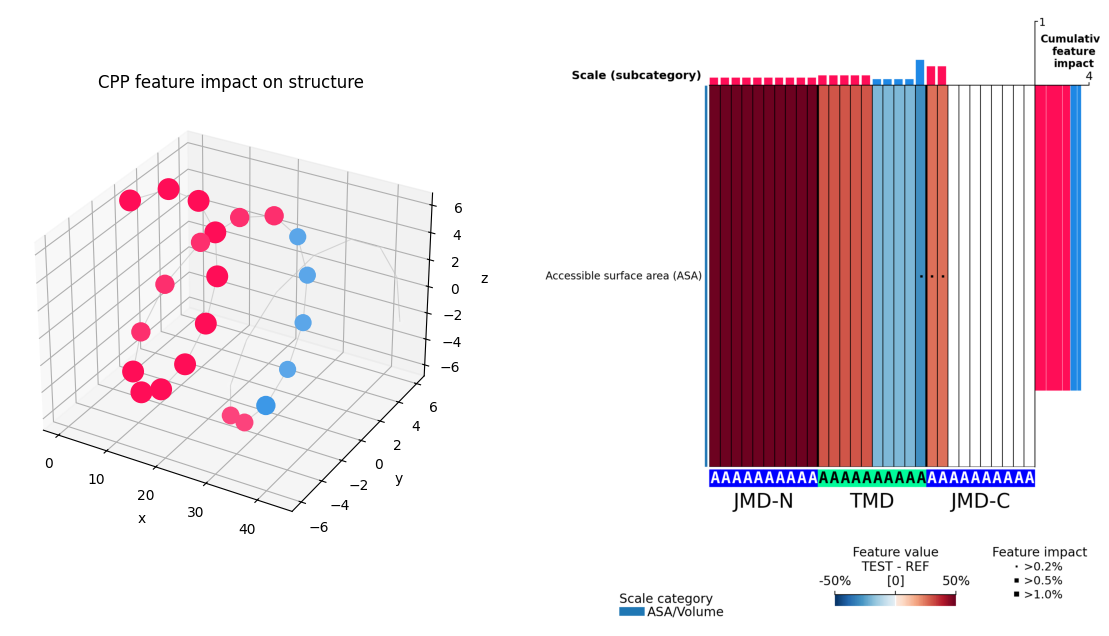

In [3]:
csp = aa.CPPStructurePlot(jmd_n_len=10, jmd_c_len=10, verbose=False)
fig, ax = csp.plot_combined(df_feat=df_feat, pdb=pdb, col_imp='feat_impact',
                            tmd_len=10, start=1, mode='impact', focus='fade',
                            tmd_seq='A'*10, jmd_n_seq='A'*10, jmd_c_seq='A'*10)
plt.show()

## App-exact vs. span-normalized colouring

By default (`normalize_by_span=False`) each feature's **full** impact lands on every residue it spans — matching the deployed app. Set `normalize_by_span=True` for the span-normalized sum used by the `feature_map` top per-position bar (each feature's impact divided by the number of residues it spans).

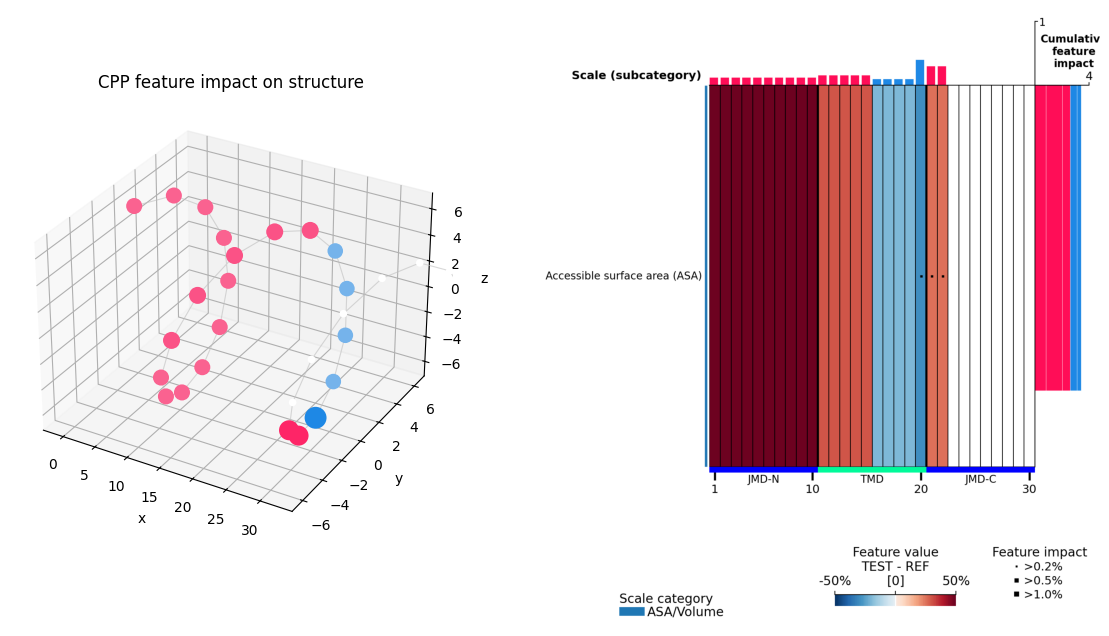

In [4]:
fig, ax = csp.plot_combined(df_feat=df_feat, pdb=pdb, col_imp='feat_impact',
                            tmd_len=10, mode='impact', focus='zoom',
                            normalize_by_span=True)
plt.show()

## pLDDT confidence mode and saving

`mode="plddt"` paints the AlphaFold confidence palette on the structure (blue = high, orange = low) while the feature map stays unchanged. The whole figure exports with `savefig` to PNG or PDF (the feature-map panel is embedded as a high-resolution raster).

wrote combined.png ( 173566 bytes )


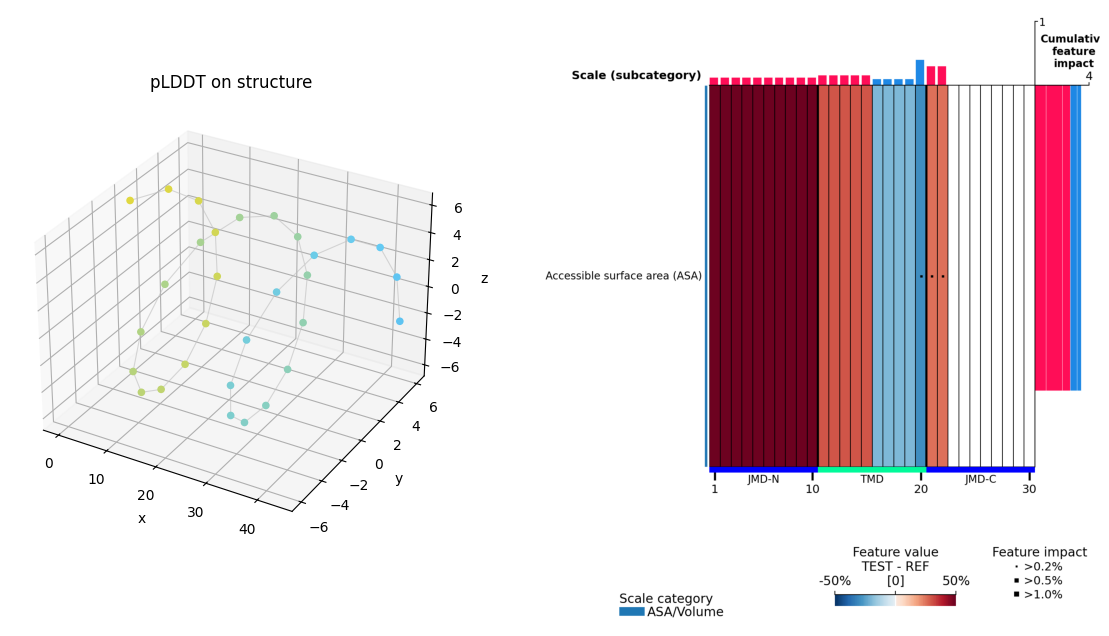

In [5]:
fig, ax = csp.plot_combined(df_feat=df_feat, pdb=pdb, col_imp='feat_impact',
                            tmd_len=10, mode='plddt', focus='whole')
out_png = os.path.join(tmp, 'combined.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print('wrote', os.path.basename(out_png), '(', os.path.getsize(out_png), 'bytes )')
plt.show()

To fetch the structure straight from AlphaFold DB, pass `uniprot=` instead of `pdb=`:

```python
fig, ax = csp.plot_combined(df_feat=df_feat, uniprot='Q9NQ76', tmd_len=10, start=312)
fig.savefig('adamts7_combined.pdf')
```